# Spooky Author Identification — methodology 1: Naive-Bayes-weighted n-gram logistic regression

Kaggle: https://www.kaggle.com/competitions/spooky-author-identification — decide which of three horror authors (Edgar Allan Poe **EAP**,
H. P. Lovecraft **HPL**, Mary Shelley **MWS**) wrote a sentence. 19,579 training sentences, 8,392 test sentences; scored by multiclass **log loss**
(lower is better). No pre-trained models anywhere in this study.

**Method.** Word 1–2-grams and character 1–5-grams (case and punctuation preserved) are TF-IDF weighted (sublinear term frequency).
For each author $c$ a binary (one-vs-rest) logistic regression is fitted on features rescaled by the Naive Bayes log-count ratio
(Wang & Manning, 2012):
$$r^{(c)}=\log\frac{p^{(c)}/\lVert p^{(c)}\rVert_1}{q^{(c)}/\lVert q^{(c)}\rVert_1},\quad p^{(c)}=1+\sum_{y_i=c}x_i,\; q^{(c)}=1+\sum_{y_i\ne c}x_i,\qquad \tilde x=r^{(c)}\circ x .$$
The three binary probabilities are normalised to sum to one. The inverse regularisation strength $C\in\{10,30,100\}$ is chosen by out-of-fold log loss, and the
probabilities are then temperature-scaled, $p\mapsto\mathrm{softmax}(\log p/T)$, with $T$ fitted **on the other folds' out-of-fold predictions** (so the reported number never saw its own labels).

Features are fitted on each fold's training rows only (`spooky_features.py`); the fits were run by `train_nblr.py` (resumable, one saved record per fit).

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import sparse
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
import spooky_common as S, train_nblr as T
from spooky_features import CACHE
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868"]; AU = S.AUTHORS
os.makedirs("assets", exist_ok=True)
train, test, folds, y = S.load(); prior = np.tile(np.bincount(y) / len(y), (len(y), 1))
print("class-prior reference log loss:", round(S.sample_loss(y, prior).mean(), 4))

class-prior reference log loss: 1.0875


## 1. Regularisation sweep (the in-training view of a model without epochs)

For each $C$: out-of-fold log loss before and after cross-validated temperature scaling, per-fold spread, and the fitted temperature.

,C,raw_log_loss,calibrated_log_loss,accuracy,mean_T,fold_sd
0,10,0.3755,0.3494,0.8676,0.6798,0.0068
1,30,0.3473,0.3441,0.8719,0.8748,0.0075
2,100,0.3498,0.3464,0.8705,1.1447,0.0086


selected C = 30


final (calibrated): log loss 0.3441 [0.3343 0.3547]  accuracy 0.8719  macro-F1 0.8719  per-author F1 {'EAP': 0.874, 'HPL': 0.878, 'MWS': 0.864}


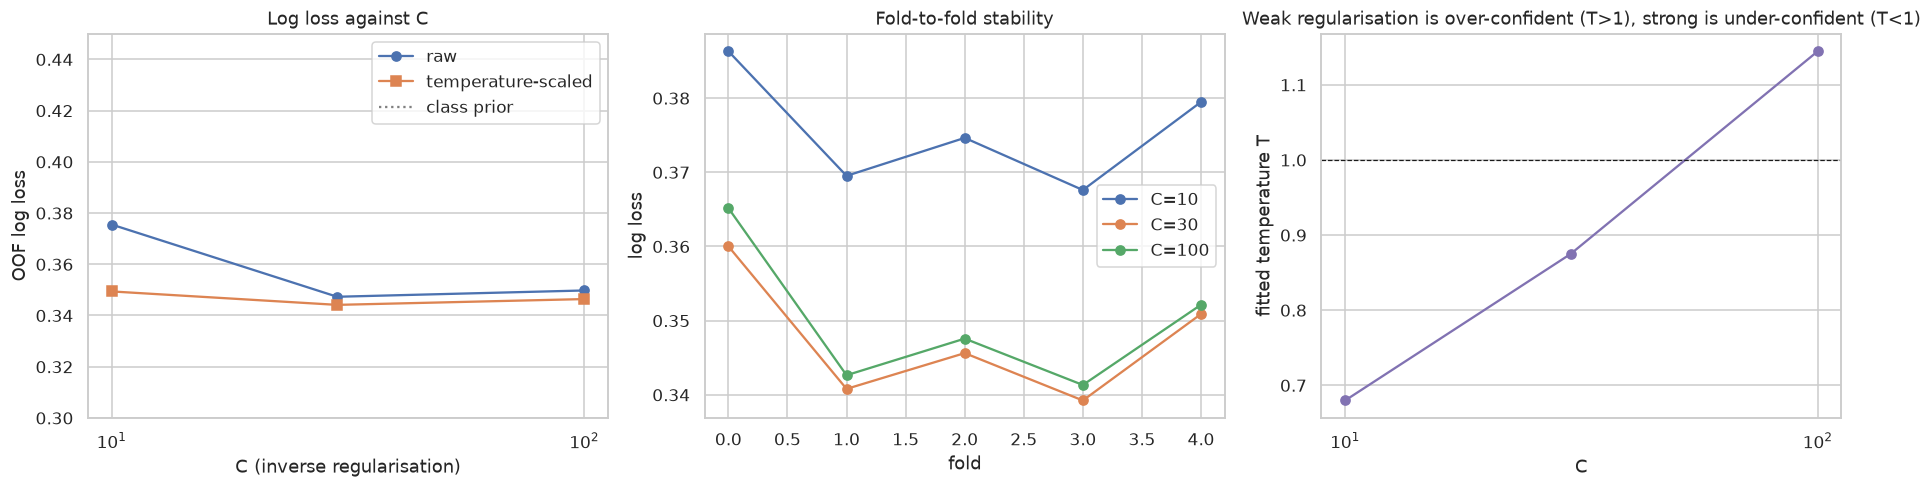

In [2]:
rows, OOF = [], {}
for Cc in T.C_GRID:
    oof, tst = T.assemble(Cc, folds, len(test)); cal, Ts, tcal = S.cv_temperature(oof, y, folds, tst); OOF[Cc] = (oof, tst, cal, tcal, Ts)
    e, ec = S.evaluate(y, oof, folds, 200), S.evaluate(y, cal, folds, 200)
    rows.append(dict(C=Cc, raw_log_loss=e["log_loss"], calibrated_log_loss=ec["log_loss"], accuracy=e["accuracy"], mean_T=np.mean(Ts), fold_sd=np.std(e["fold_log_loss"])))
sweep = pd.DataFrame(rows); display(sweep.round(4)); best_C = int(sweep.loc[sweep.raw_log_loss.idxmin(), "C"]); print("selected C =", best_C)
oof, tst, cal, tcal, Ts = OOF[best_C]; ev_raw, ev = S.evaluate(y, oof, folds), S.evaluate(y, cal, folds)
print(f"final (calibrated): log loss {ev['log_loss']:.4f} {np.round(ev['log_loss_ci95'], 4)}  accuracy {ev['accuracy']:.4f}  macro-F1 {ev['macro_f1']:.4f}  per-author F1 { {k: round(v, 3) for k, v in ev['f1_per_author'].items()} }")
S.save_method("nblr", cal, tcal, dict(method="NB-weighted n-gram logistic regression (one-vs-rest)", C=best_C, temperature_per_fold=Ts, raw=ev_raw, **ev))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].plot(sweep.C, sweep.raw_log_loss, "o-", label="raw"); axes[0].plot(sweep.C, sweep.calibrated_log_loss, "s-", label="temperature-scaled"); axes[0].axhline(S.sample_loss(y, prior).mean(), color="grey", ls=":", label="class prior")
axes[0].set_xscale("log"); axes[0].set_ylim(0.3, 0.45); axes[0].set_xlabel("C (inverse regularisation)"); axes[0].set_ylabel("OOF log loss"); axes[0].legend(); axes[0].set_title("Log loss against C")
for Cc in T.C_GRID: axes[1].plot(range(5), S.evaluate(y, OOF[Cc][0], folds, 10)["fold_log_loss"], "o-", label=f"C={Cc}")
axes[1].set_xlabel("fold"); axes[1].set_ylabel("log loss"); axes[1].set_title("Fold-to-fold stability"); axes[1].legend()
axes[2].plot(sweep.C, sweep.mean_T, "o-", color="#8172B2"); axes[2].axhline(1, color="k", lw=.8, ls="--"); axes[2].set_xscale("log"); axes[2].set_xlabel("C"); axes[2].set_ylabel("fitted temperature T")
axes[2].set_title("Weak regularisation is over-confident (T>1), strong is under-confident (T<1)")
plt.tight_layout(); plt.savefig("assets/nblr_01_regularisation_sweep.png", bbox_inches="tight"); plt.show()

## 2. Post-training diagnostics

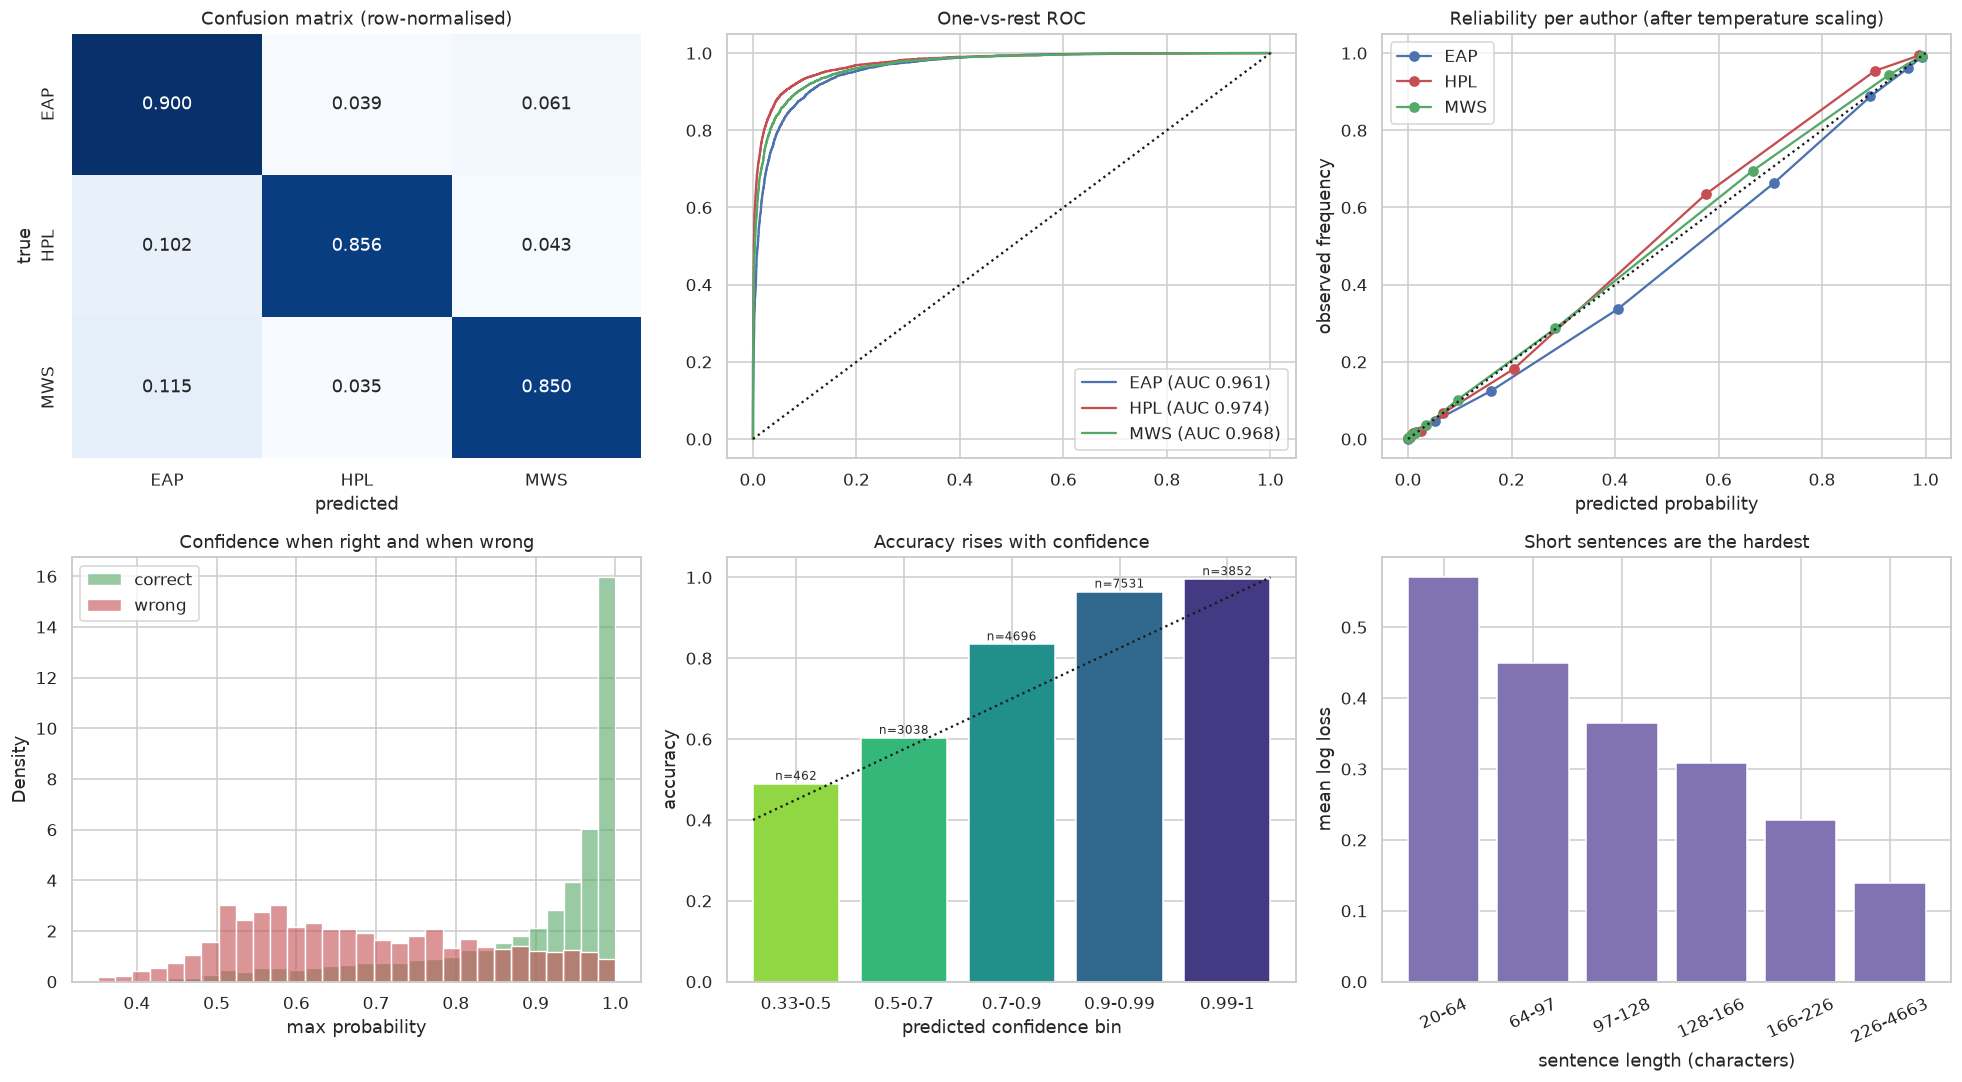

In [3]:
pred = cal.argmax(1); fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cm = confusion_matrix(y, pred, normalize="true"); sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", ax=axes[0, 0], cbar=False, xticklabels=AU, yticklabels=AU); axes[0, 0].set_xlabel("predicted"); axes[0, 0].set_ylabel("true"); axes[0, 0].set_title("Confusion matrix (row-normalised)")
for c in range(3):
    f, t, _ = roc_curve(y == c, cal[:, c]); axes[0, 1].plot(f, t, color=PAL[c], label=f"{AU[c]} (AUC {roc_auc_score(y == c, cal[:, c]):.3f})")
axes[0, 1].plot([0, 1], [0, 1], "k:"); axes[0, 1].legend(); axes[0, 1].set_title("One-vs-rest ROC")
for c in range(3):
    fp, mp = calibration_curve(y == c, cal[:, c], n_bins=10, strategy="quantile"); axes[0, 2].plot(mp, fp, "o-", color=PAL[c], label=AU[c])
axes[0, 2].plot([0, 1], [0, 1], "k:"); axes[0, 2].set_xlabel("predicted probability"); axes[0, 2].set_ylabel("observed frequency"); axes[0, 2].legend(); axes[0, 2].set_title("Reliability per author (after temperature scaling)")
conf = cal.max(1); right = pred == y
sns.histplot(x=conf[right], bins=30, stat="density", color="#55A868", alpha=.6, label="correct", ax=axes[1, 0]); sns.histplot(x=conf[~right], bins=30, stat="density", color="#C44E52", alpha=.6, label="wrong", ax=axes[1, 0]); axes[1, 0].legend(); axes[1, 0].set_xlabel("max probability"); axes[1, 0].set_title("Confidence when right and when wrong")
bins = pd.cut(conf, [0.33, 0.5, 0.7, 0.9, 0.99, 1.0]); acc = pd.DataFrame({"b": bins, "ok": right}).groupby("b", observed=True).ok.agg(["mean", "size"]); axes[1, 1].bar(range(len(acc)), acc["mean"], color=sns.color_palette("viridis_r", len(acc)))
axes[1, 1].set_xticks(range(len(acc)), [f"{i.left:g}-{i.right:g}" for i in acc.index]); axes[1, 1].plot([-.4, len(acc) - .6], [.4, 1], "k:"); axes[1, 1].set_xlabel("predicted confidence bin"); axes[1, 1].set_ylabel("accuracy"); axes[1, 1].set_title("Accuracy rises with confidence")
for i, (a, n) in enumerate(zip(acc["mean"], acc["size"])): axes[1, 1].text(i, a + .01, f"n={n}", ha="center", fontsize=8)
L = train.text.str.len(); lb = pd.qcut(L, 6); ll = pd.DataFrame({"b": lb, "nll": S.sample_loss(y, cal)}).groupby("b", observed=True).nll.mean(); axes[1, 2].bar(range(len(ll)), ll.values, color="#8172B2")
axes[1, 2].set_xticks(range(len(ll)), [f"{int(i.left)}-{int(i.right)}" for i in ll.index], rotation=25); axes[1, 2].set_xlabel("sentence length (characters)"); axes[1, 2].set_ylabel("mean log loss"); axes[1, 2].set_title("Short sentences are the hardest")
plt.tight_layout(); plt.savefig("assets/nblr_02_post_training_diagnostics.png", bbox_inches="tight"); plt.show()

### What the model learned: the largest log-count ratios per author

Computed on fold 0's training rows. Words and character n-grams that occur in at least 8 and 30 training sentences respectively, so single rare tokens do not dominate.

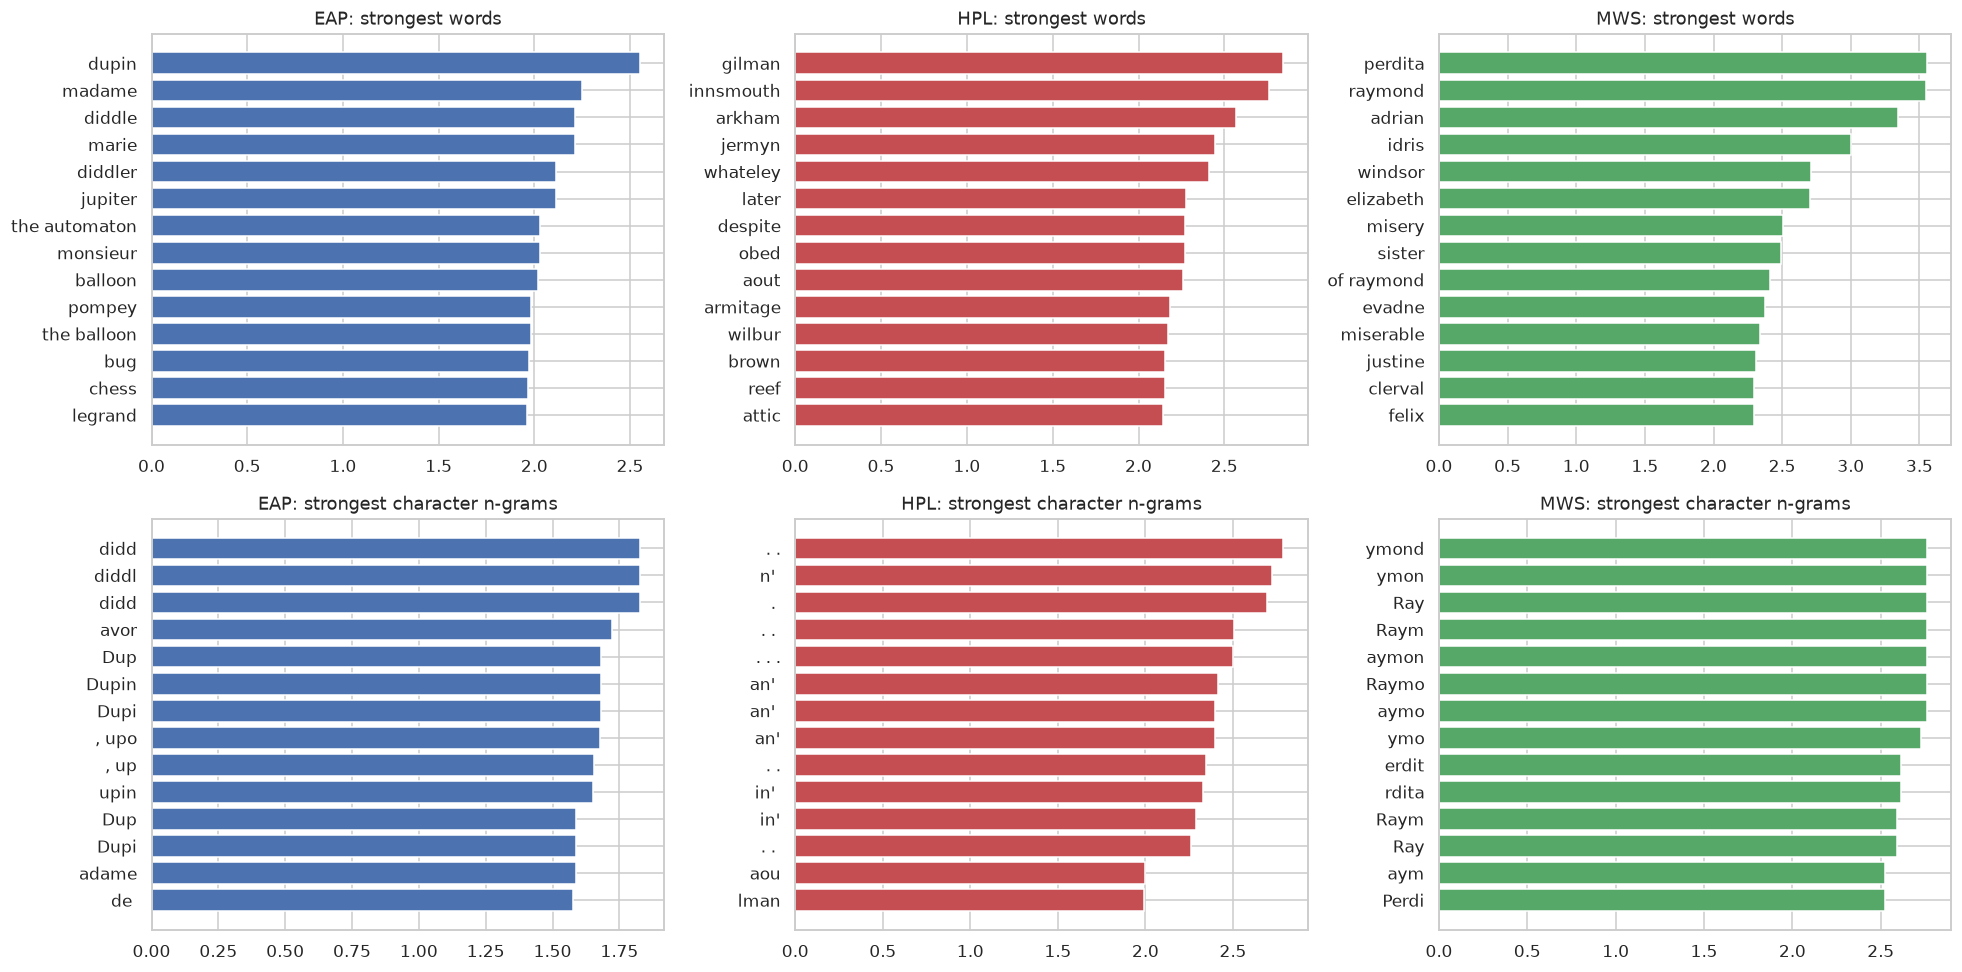

In [4]:
names = np.load(os.path.join(CACHE, "f0_names.npy"), allow_pickle=True); X0 = sparse.load_npz(os.path.join(CACHE, "f0_train.npz")).tocsr(); tr0 = np.where(folds != 0)[0]
df = np.asarray((X0 > 0).sum(0)).ravel(); isw = np.array([n.startswith("w:") for n in names]); fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for c in range(3):
    r = T.nb_ratio(X0, (y[tr0] == c).astype(int))
    for row, (mask, mn, lab) in enumerate([(isw & (df >= 8), 8, "words"), (~isw & (df >= 30), 30, "character n-grams")]):
        idx = np.where(mask)[0]; top = idx[np.argsort(-r[idx])[:14]][::-1]
        axes[row, c].barh([repr(names[i][2:])[1:-1] for i in top], r[top], color=PAL[c]); axes[row, c].set_title(f"{AU[c]}: strongest {lab}")
plt.tight_layout(); plt.savefig("assets/nblr_03_log_count_ratios.png", bbox_inches="tight"); plt.show()

### The most confident mistakes

In [5]:
pd.set_option("display.max_colwidth", 150); E = train.assign(true=train.author, pred=[AU[i] for i in pred], p_pred=cal.max(1), p_true=cal[np.arange(len(y)), y])
wrong = E[E.true != E.pred].sort_values("p_pred", ascending=False); display(wrong.head(8)[["true", "pred", "p_pred", "text"]])
print(f"errors: {len(wrong)} of {len(E)} ({len(wrong) / len(E):.1%}); mean confidence on errors {wrong.p_pred.mean():.3f}")
sd = S.evaluate(y, cal, folds)["fold_log_loss"]; print("per-fold log loss:", np.round(sd, 4), "sd", round(float(np.std(sd)), 4))

,true,pred,p_pred,text
8242,EAP,HPL,0.999300,"""Strange you shouldn't know me, though, isn't it?"
6633,MWS,EAP,0.996669,"As the minuteness of the parts formed a great hindrance to my speed, I resolved, contrary to my first intention, to make the being of a gigantic s..."
2669,EAP,MWS,0.996046,"""He had married,"" he said, ""for love, and for love only; and his bride was far more than worthy of his love."""
10729,HPL,EAP,0.995830,"""Don't move,"" he cautioned, ""for in these rays we are able to be seen as well as to see."
5743,HPL,MWS,0.995493,"She was greatly devoted to her unfortunate sister, and had an especial affection for her only surviving nephew William, who from a sturdy infant h..."
831,MWS,EAP,0.995197,Calderon de la Barca.
11079,MWS,EAP,0.994632,"""It is not from deck,"" said the man at the helm, ""something has been thrown from the aft cabin."""
12053,HPL,EAP,0.993425,"We even avoid looking at it very steadily."""


errors: 2508 of 19579 (12.8%); mean confidence on errors 0.682
per-fold log loss: [0.359  0.3369 0.342  0.3348 0.348 ] sd 0.0087
